# ## Section 1: Initialize Environment

In [1]:
import sys, os

# Hadoop configuration
HADOOP_BASE = r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\hadoop'
os.environ['JAVA_HOME'] = r'C:\Users\yrghimire\.jdks\corretto-1.8.0_482'
os.environ['HADOOP_HOME'] = HADOOP_BASE
os.environ['hadoop.home.dir'] = HADOOP_BASE
os.environ['PATH'] = os.path.join(HADOOP_BASE, 'bin') + ';' + os.environ.get('PATH', '')
os.environ['PYSPARK_PYTHON'] = sys.executable

os.makedirs(r'C:\tmp\hive', exist_ok=True)
os.makedirs(r'C:\tmp\spark', exist_ok=True)

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import ArrayType, FloatType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# PyTorch + PyTorch Geometric
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

# Others
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from skimage.segmentation import slic
from scipy.spatial import distance_matrix
from tqdm import tqdm
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

# Start Spark
spark = SparkSession.builder \
    .appName("GNN_Alzheimer_PySpark") \
    .master("local[*]") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("PySpark initialized")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")

Libraries imported
PySpark initialized
PyTorch device: cuda


# ## Section 2: Configuration

In [2]:
CONFIG = {
    'DATA_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Alzheimer_MRI_4_classes_dataset',
    'OUTPUT_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3b',
    
    'IMG_SIZE': 128,
    'NUM_SUPERPIXELS': 75,
    'COMPACTNESS': 10,
    'K_NEIGHBORS': 8,
    
    'GCN_HIDDEN_DIM': 256,
    'FEATURE_DIM': 256,  # GNN output dim
    
    'CLASS_NAMES': ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented'],
    'NUM_CLASSES': 4,
    
    'TRAIN_SPLIT': 0.8,
    'TEST_SPLIT': 0.2,
    
    'MAX_ITER': 100,
    'REG_PARAM': 0.01,
    
    'RANDOM_SEED': 42
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)
print("Configuration loaded")

Configuration loaded


# ## Section 3: Graph Construction Functions

In [3]:
def extract_node_features(image, segments):
    """Extract features for each superpixel"""
    num_segments = segments.max() + 1
    features = []
    centroids = []
    
    from skimage.color import rgb2gray
    gray_image = rgb2gray(image)
    
    for seg_id in range(num_segments):
        mask = segments == seg_id
        region_pixels = image[mask]
        
        mean_color = region_pixels.mean(axis=0)
        std_color = region_pixels.std(axis=0)
        
        coords = np.argwhere(mask)
        centroid = coords.mean(axis=0)
        area = mask.sum()
        
        norm_centroid = centroid / np.array(image.shape[:2])
        norm_area = area / (image.shape[0] * image.shape[1])
        
        node_feature = np.concatenate([
            mean_color, std_color, norm_centroid, [norm_area]
        ])
        
        features.append(node_feature)
        centroids.append(centroid)
    
    return np.array(features), np.array(centroids)


def construct_graph(image_path):
    """Convert image to graph"""
    image = Image.open(image_path).convert('RGB')
    image = image.resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
    image = np.array(image) / 255.0
    
    segments = slic(image, n_segments=CONFIG['NUM_SUPERPIXELS'], 
                   compactness=CONFIG['COMPACTNESS'], start_label=0)
    
    node_features, centroids = extract_node_features(image, segments)
    
    dist_matrix = distance_matrix(centroids, centroids)
    edge_index = []
    
    for i in range(len(centroids)):
        distances = dist_matrix[i]
        nearest = np.argsort(distances)[1:CONFIG['K_NEIGHBORS']+1]
        for j in nearest:
            edge_index.append([i, j])
    
    edge_index = np.array(edge_index).T
    
    x = torch.FloatTensor(node_features)
    edge_index = torch.LongTensor(edge_index)
    
    return x, edge_index


print("Graph construction functions defined")

Graph construction functions defined


# ## Section 4: GNN Feature Encoder

In [4]:
class GNNEncoder(nn.Module):
    """GNN model for extracting graph-level features"""
    
    def __init__(self, node_feature_dim, hidden_dim, output_dim):
        super(GNNEncoder, self).__init__()
        
        self.conv1 = GCNConv(node_feature_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, output_dim)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        
        x = self.conv3(x, edge_index)
        x = torch.relu(x)
        
        # Global pooling
        x = global_mean_pool(x, batch)
        
        return x


# Create encoder
node_feature_dim = 9  # RGB (3) + std (3) + position (2) + area (1)
encoder = GNNEncoder(node_feature_dim, CONFIG['GCN_HIDDEN_DIM'], CONFIG['FEATURE_DIM']).to(device)
encoder.eval()

print("GNN encoder created")


GNN encoder created


# ## Section 5: Load Data and Extract Features

In [5]:
print("Loading images and extracting graph features...")
print("This takes 30-50 minutes...\n")

all_images = []
all_labels = []

for class_idx, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_dir = os.path.join(CONFIG['DATA_DIR'], class_name)
    if os.path.exists(class_dir):
        image_files = [f for f in os.listdir(class_dir) 
                      if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_file in image_files:
            all_images.append(os.path.join(class_dir, img_file))
            all_labels.append(class_idx)
        
        print(f"  {class_name}: {len(image_files)} images")

print(f"\nTotal: {len(all_images):,} images")

# Shuffle
np.random.seed(CONFIG['RANDOM_SEED'])
indices = np.random.permutation(len(all_images))
all_images = np.array(all_images)[indices]
all_labels = np.array(all_labels)[indices]

# Extract features
all_features = []

print("\nExtracting GNN features...")
with torch.no_grad():
    for img_path, label in tqdm(zip(all_images, all_labels), total=len(all_images)):
        try:
            x, edge_index = construct_graph(img_path)
            
            # Create batch
            batch = torch.zeros(x.size(0), dtype=torch.long)
            
            data = Data(x=x, edge_index=edge_index, batch=batch).to(device)
            
            features = encoder(data)
            all_features.append(features.cpu().numpy().flatten())
        except:
            all_features.append(np.zeros(CONFIG['FEATURE_DIM']))

features_array = np.array(all_features)
print(f"\nFeatures extracted: {features_array.shape}")

Loading images and extracting graph features...
This takes 30-50 minutes...

  MildDemented: 896 images
  ModerateDemented: 64 images
  NonDemented: 3200 images
  VeryMildDemented: 2240 images

Total: 6,400 images

Extracting GNN features...


100%|██████████| 6400/6400 [08:46<00:00, 12.17it/s]


Features extracted: (6400, 256)


# ## Section 6: Prepare PySpark DataFrame

In [7]:
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.types import StructType, StructField, LongType

print("Creating PySpark DataFrame...")

# Build Vectors.dense in Python (avoids UDF serialization issues)
pandas_data = pd.DataFrame({
    'id': np.arange(len(features_array), dtype=np.int64),
    'label': all_labels.astype(np.int64),
    'features': [Vectors.dense(features_array[i]) for i in range(len(features_array))]
})

schema = StructType([
    StructField("id", LongType(), False),
    StructField("label", LongType(), False),
    StructField("features", VectorUDT(), False),
])

ml_df = spark.createDataFrame(pandas_data, schema=schema)

print("PySpark DataFrame created")

# Split
train_df, test_df = ml_df.randomSplit([CONFIG['TRAIN_SPLIT'], CONFIG['TEST_SPLIT']], seed=CONFIG['RANDOM_SEED'])
train_df = train_df.cache()
test_df = test_df.cache()

train_count = train_df.count()
test_count = test_df.count()

print(f"\nSplit:")
print(f"   Training: {train_count:,}")
print(f"   Test:     {test_count:,}")

Creating PySpark DataFrame...
PySpark DataFrame created

Split:
   Training: 5,134
   Test:     1,266


# ## Section 7: Train Classifier

In [8]:
print("="*80)
print("TRAINING WITH PYSPARK")
print("="*80)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=CONFIG['MAX_ITER'], 
                        regParam=CONFIG['REG_PARAM'], family="multinomial")

pipeline = Pipeline(stages=[scaler, lr])

print("\nTraining...")
import time
start = time.time()
model = pipeline.fit(train_df)
train_time = time.time() - start

print(f"Training complete in {train_time:.2f}s")

TRAINING WITH PYSPARK

Training...
Training complete in 41.23s


# ## Section 8: Evaluate

In [9]:
print("="*80)
print("EVALUATION")
print("="*80)

predictions = model.transform(test_df).cache()

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

f1_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
f1 = f1_evaluator.evaluate(predictions)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"F1-Score: {f1:.4f}")

# Convert to pandas
predictions_pd = predictions.select('label', 'prediction', 'probability').toPandas()

EVALUATION

Test Accuracy: 55.21%
F1-Score: 0.5276


# ## Section 9: Confusion Matrix

Confusion matrix saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3b\confusion_matrix.png


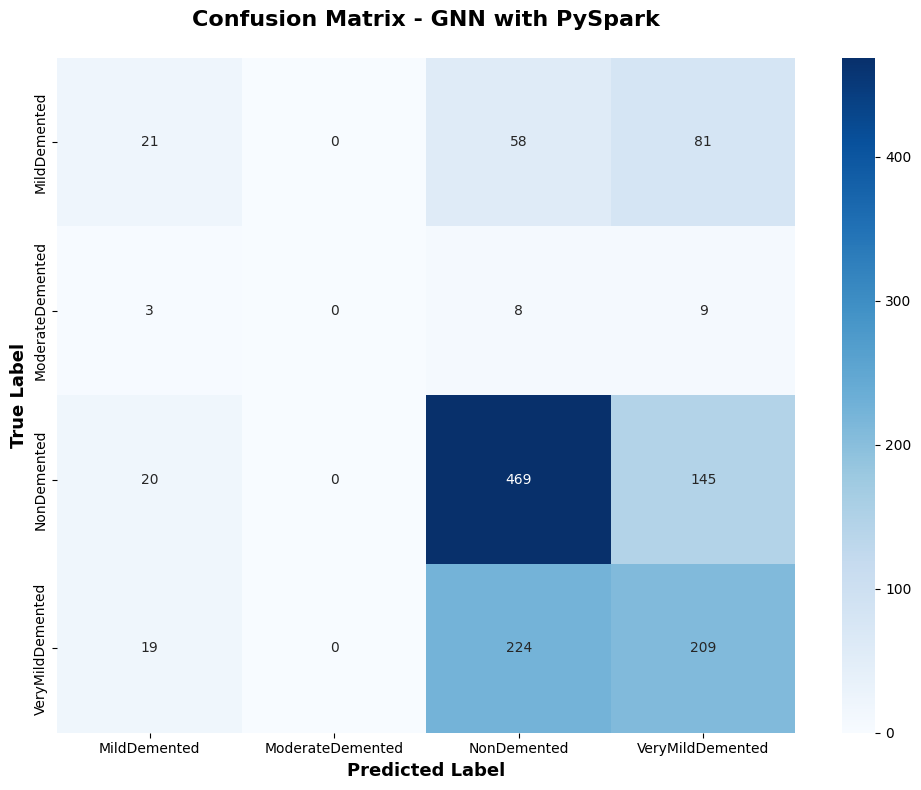


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    MildDemented     0.3333    0.1313    0.1883       160
ModerateDemented     0.0000    0.0000    0.0000        20
     NonDemented     0.6179    0.7397    0.6734       634
VeryMildDemented     0.4707    0.4624    0.4665       452

        accuracy                         0.5521      1266
       macro avg     0.3555    0.3333    0.3321      1266
    weighted avg     0.5196    0.5521    0.5276      1266



In [10]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = predictions_pd['label'].values
y_pred = predictions_pd['prediction'].values

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CONFIG['CLASS_NAMES'], yticklabels=CONFIG['CLASS_NAMES'])
plt.title('Confusion Matrix - GNN with PySpark\n', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(CONFIG['OUTPUT_DIR'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix saved to: {cm_path}")
plt.show()

print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
report = classification_report(y_true, y_pred, target_names=CONFIG['CLASS_NAMES'], digits=4)
print(report)

# ## Section 10: ROC Curves

Generating ROC curves...
ROC curves saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3b\roc_curves.png


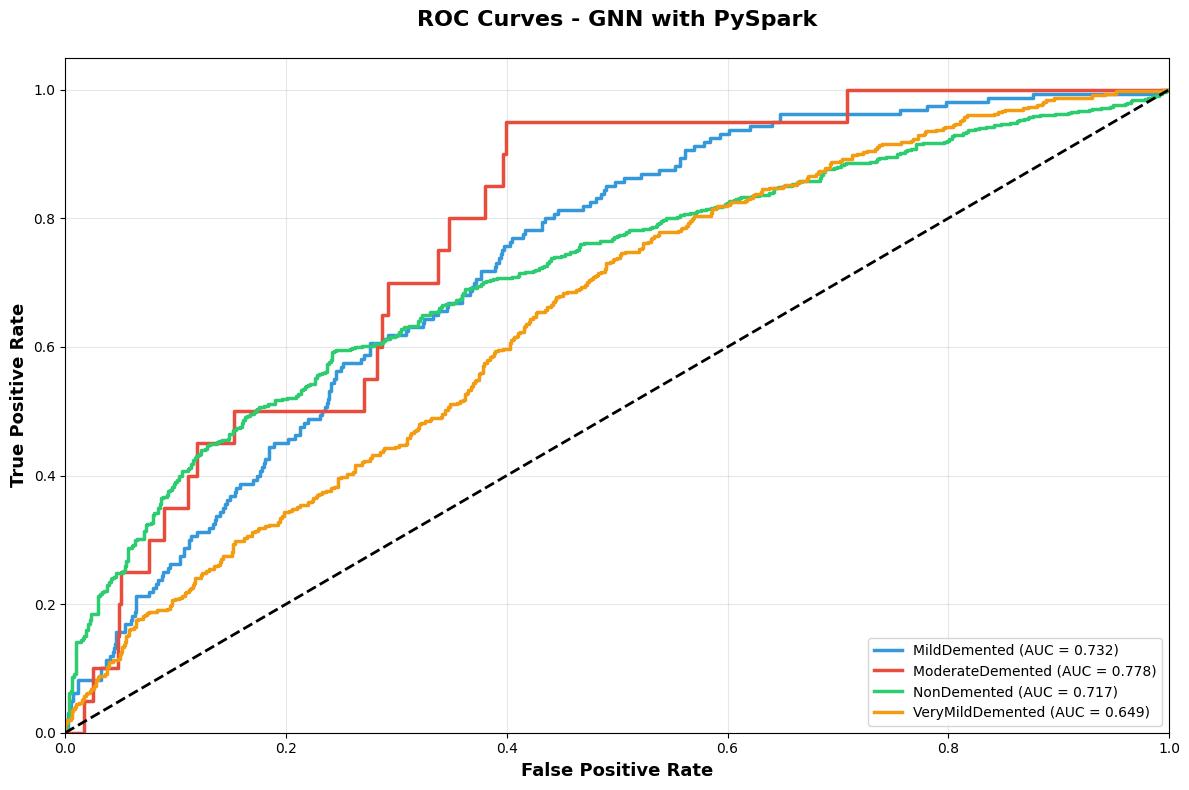


AUC Scores:
   MildDemented        : 0.7324
   ModerateDemented    : 0.7780
   NonDemented         : 0.7166
   VeryMildDemented    : 0.6492
   Average             : 0.7190


In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Generating ROC curves...")

y_score = np.array([list(p) for p in predictions_pd['probability'].values])
y_test_bin = label_binarize(y_true, classes=range(CONFIG['NUM_CLASSES']))

plt.figure(figsize=(12, 8))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
auc_scores = []

for i, (class_name, color) in enumerate(zip(CONFIG['CLASS_NAMES'], colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - GNN with PySpark\n', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(CONFIG['OUTPUT_DIR'], 'roc_curves.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"ROC curves saved to: {roc_path}")
plt.show()

print("\nAUC Scores:")
for class_name, auc_score in zip(CONFIG['CLASS_NAMES'], auc_scores):
    print(f"   {class_name:20s}: {auc_score:.4f}")
print(f"   {'Average':20s}: {np.mean(auc_scores):.4f}")

# ## Section 11: Save Results

In [12]:
results = {
    'model': 'GNN with PySpark (GNN Feature Extraction + PySpark LR)',
    'dataset': 'Alzheimer MRI 4-class',
    'test_accuracy': float(accuracy),
    'test_f1_score': float(f1),
    'training_time_seconds': train_time,
    'num_train_samples': train_count,
    'num_test_samples': test_count,
    'gnn_feature_dim': CONFIG['FEATURE_DIM'],
    'class_names': CONFIG['CLASS_NAMES'],
    'auc_scores': {name: float(score) for name, score in zip(CONFIG['CLASS_NAMES'], auc_scores)}
}

results_path = os.path.join(CONFIG['OUTPUT_DIR'], 'final_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

report_path = os.path.join(CONFIG['OUTPUT_DIR'], 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write(report)

print("\n" + "="*80)
print("Q3b COMPLETE - GNN WITH PYSPARK!")
print("="*80)
print(f"\nOutput directory: {CONFIG['OUTPUT_DIR']}")
print("\nGenerated files:")
print("   1. confusion_matrix.png")
print("   2. roc_curves.png")
print("   3. classification_report.txt")
print("   4. final_results.json")
print(f"\nFinal Accuracy: {accuracy*100:.2f}%")

spark.stop()
print("\nPySpark session stopped")



Q3b COMPLETE - GNN WITH PYSPARK!

Output directory: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q3\Q3b

Generated files:
   1. confusion_matrix.png
   2. roc_curves.png
   3. classification_report.txt
   4. final_results.json

Final Accuracy: 55.21%

PySpark session stopped
